# 08 Optional: Staggered Timing Preview

Real treatments often do not start at the same time for every
treated unit. This preview introduces the language of cohorts,
treatment month, and event time. It is not a full modern DiD
estimator lesson, and the simple coefficient below should be
read as descriptive. With staggered adoption and dynamic or
heterogeneous effects, a simple two-way fixed-effects treatment
indicator can mix comparisons across cohorts in ways that are
not a clean 2x2 DiD contrast.


In [1]:
from lite_setup import ensure_packages
await ensure_packages()

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf

from checks import check_close, check_columns, check_same_estimate, check_sign
from did_utils import (
    did_2x2_table,
    manual_did,
    predicted_values_2x2,
    plot_group_trends,
    plot_did_counterfactual,
    make_event_dummies,
    extract_event_study_results,
    plot_event_study,
)


plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("data")


Running outside JupyterLite; assuming packages are already installed.


In [2]:
df = pd.read_csv(DATA_DIR / "staggered_rollout_preview.csv")
df.head()


,unit_id,month,cohort,treat_month,ever_treated,currently_treated,relative_time,outcome
0,U001,1,early,9.0,1,0,-8.0,72.34
1,U001,2,early,9.0,1,0,-7.0,72.19
2,U001,3,early,9.0,1,0,-6.0,72.33
3,U001,4,early,9.0,1,0,-5.0,73.95
4,U001,5,early,9.0,1,0,-4.0,73.26


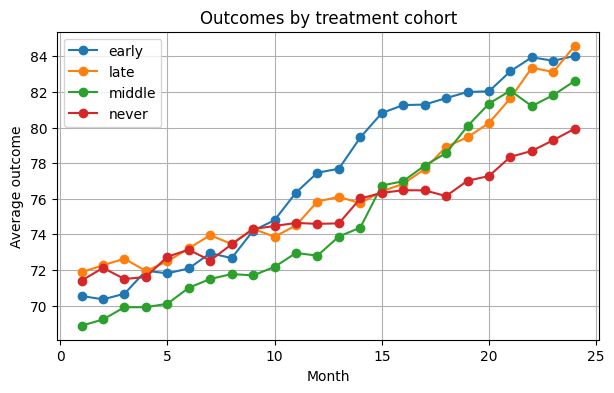

In [3]:
cohort_trends = df.groupby(["month", "cohort"], as_index=False)["outcome"].mean()
fig, ax = plt.subplots()
for cohort, part in cohort_trends.groupby("cohort"):
    ax.plot(part["month"], part["outcome"], marker="o", label=cohort)
ax.set_xlabel("Month")
ax.set_ylabel("Average outcome")
ax.set_title("Outcomes by treatment cohort")
ax.legend()
plt.show()


In [4]:
df.groupby("cohort")[["treat_month", "ever_treated"]].first()


,treat_month,ever_treated
cohort,,
early,9.0,1
late,17.0,1
middle,13.0,1
never,NaN,0


In [5]:
twfe_preview = smf.ols(
    "outcome ~ currently_treated + C(unit_id) + C(month)",
    data=df,
).fit(cov_type="cluster", cov_kwds={"groups": df["unit_id"]})

twfe_preview.params["currently_treated"], twfe_preview.bse["currently_treated"]


(np.float64(2.746598837209307), np.float64(0.24562274510779453))

Takeaway: the 2x2 DiD logic is the foundation, but staggered
treatment timing requires extra care. In real applications you
should think about cohorts, event time, never-treated or
not-yet-treated comparisons, dynamic treatment effects, and
estimators designed for staggered adoption.
